# Pràctica 1: Identificació d'idiomes

Jaume Majó i David Vàzquez

L'objectiu d'aquesta pràctica és implementar un identificador d'idiomes (basat en trigrames de caràcters) de les principals llengües europees: anglès, castellà, neerlandès, alemany, italià i francès. Per fer-ho, ens basarem amb el corpus wortschatz leipzig que conté textos de forma i mida similar en els diferents idiomes esmentats.

## 1. Importem les llibreries
En primer lloc importem les llibreries necessàries per a la implementeció de l'identificador d'idiomes. 

In [2]:
import nltk
import re
import os
from math import log, exp
from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder, QuadgramCollocationFinder
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

## 2. Preprocessing
A continuació, creem una funció `preprocessing(file_path)` que donat un `filepath` retorna el text preprocessat d'aquest fitxer. El preprocessament consta dels seguents passos:
- Eliminar els símbols que es troben entre números i al final d'aquests ja que si no, en llengües com l'alemany (que al final dels números s'ha de posar un punt), quedaven punts aïllats.
- Eliminar els números.
- Substituir espais dobles per un únic espai.
- Convertir tot el text a minúscula.
- Concatenar totes les frases amb separació de 2 espais. D'aquesta manera, com que utilitzarem trigrames, ens asegurem que no hi haurà un trigrama amb parts de dues frases diferents.

In [3]:
def preprocessing(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        raw_text = file.read()
    cleaned_text = re.sub(r'(\d)[.:](\d)', r'\1\2', raw_text) # Eliminar simbols adjacents tambe dp
    cleaned_text = re.sub(r'\d+', '', cleaned_text)  # Remove digits
    cleaned_text = re.sub(r'[ \t]+', ' ', cleaned_text)
    cleaned_text = cleaned_text.lower()  # Convert to lowercase
    #nltk_sent = nltk.sent_tokenize(cleaned_text)
    #result = "  ".join(nltk_sent)
    cleaned_text = cleaned_text.replace("\n", "  ")
    cleaned_text = re.sub(r' {2,}', '  ', cleaned_text)
    cleaned_text = '  ' + cleaned_text.strip() + '  '
    return cleaned_text

## 3. Càlcul de probabilitats
Definim la classe amb la que entrenarem el model per detectar l'idioma y unes funcions auxiliars per calcular el valor en la fórmula de Lidstone i el càlcul de probabilitat d'un idioma.
Iterem sobre tots els idiomes i les frases o documents i calculem la probabilitat de correspondre a cadascuna de les llengües.

In [ ]:
def absolute_discounting(trad_idioma, res, N, B, delta):
    N_0 = B - len(set(trad_idioma) & set(res))
    tot = 0
    for k, v in res.items():
        if k in trad_idioma:
            tot += v*log((trad_idioma[k] - delta)/N)
        else:
            tot += v*log(((B - N_0)*(delta / N_0))/N)
    return tot

def linear_discounting(trad_idioma, res, N, B, alpha):
    N_0 = B - len(set(trad_idioma) & set(res))
    tot = 0
    for k, v in res.items():
        if k in trad_idioma:
            tot += v*log((1 - alpha)*trad_idioma[k]/N)
        else:
            tot += v*log(alpha/N_0)
    return tot

def lidstone(trad_idioma, res, N, B, lambd):
    tot = 0
    for k, v in res.items():
        tot += v*log((trad_idioma.get(k, 0) + lambd)/(N + lambd*B))
    return tot

class IdentificadorIdiomas(BaseEstimator):

    def __init__(self, trigram = dict(), labels = [], B = dict(), N = dict(), method = "lidstone", B_compute = "unified", lambd = 0.5):
        self.trigram = trigram
        self.labels = labels
        self.B = B
        self.N = N
        self.method = method
        self.B_compute = B_compute
        self.lambd = lambd

    def prob_idioma(self, res, trad, method, lambd):
        idiomas = dict()
        if method == "lidstone":
            for k, v in trad.items():
                idiomas[k] = lidstone(v, res, self.N[k], self.B[k], lambd)
        elif method == "linear_discounting":
            for k, v in trad.items():
                idiomas[k] = linear_discounting(v, res, self.N[k], self.B[k], lambd)
        elif method == "absolute_discounting":
            for k, v in trad.items():
                idiomas[k] = absolute_discounting(v, res, self.N[k], self.B[k], lambd)
        return idiomas

    def fit(self, X, y):
        for idx, text in enumerate(X):
            finder = TrigramCollocationFinder.from_words(text)
            self.trigram.setdefault(y[idx], {})
            for k, v in finder.ngram_fd.items():
                self.trigram[y[idx]][k] = self.trigram[y[idx]].get(k, 0) + v
            self.B[y[idx]] = len(self.trigram.get(y[idx], []))
            self.N[y[idx]] = self.N.get(y[idx], 0) + sum(finder.ngram_fd.values())
        if self.B_compute == "unified":
            unique_keys = set()
            for k in self.trigram:
                unique_keys = unique_keys | set(self.trigram[k])
            for k in self.B:
                self.B[k] = len(unique_keys)
        return self

    def predict(self, X, method = None, lambd = None):
        # Pots canviar el metode per calcular les probabilitats
        method = method if method is not None else self.method
        lambd = lambd if lambd is not None else self.lambd
        traductor = dict()
        for k, v in self.trigram.items():
            traductor[k] = self.trigram[k].copy()
            traductor[k] = {key:traductor[k][key] for key in traductor[k] if traductor[k][key] >= 5}
        y_pred = []
        for text in X:
            finder = TrigramCollocationFinder.from_words(text)
            idiomes_pred = self.prob_idioma(finder.ngram_fd, traductor, method, lambd)
            idioma_pred = max(idiomes_pred, key=idiomes_pred.get)
            y_pred.append(idioma_pred)
        self.labels = [k for k in self.trigram]
        return y_pred
    
    def get_params(self, deep=True):
        return {
            "trigram": self.trigram,
            "B": self.B,
            "N": self.N,
            "method": self.method,
            "B_compute": self.B_compute,
            "lambd": self.lambd
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

Per cadascun dels idiomes, fem el preprocessament dels documents del conjunt de training. A continuació, guardem en un diccionari tots els trigrames del text preprocessat i les aparicions dels mateixos. Per després aplicar latècnica de suavitzat mitjançant lidstone, ens guardarem els valors de B i N. Prendrem com a B el número de trigrames únics vistos en tots els idiomes. Optem per aquest valor ja que es possible que diferents paraules d'un cert idioma surtin en textos d'un altre idioma. Pel que fa a la N, cadascun dels idiomes tindrà el seu propi valor que representarà el número total de trigrames vistos.

A més d'això, tal com s'especifica a l'enunciat, eliminem els trigrames amb menys de 5 aparicions en el corpus.

In [17]:
directory_path = 'langId'
traductor = dict()
X_training = []
y_training = []

for filename in os.listdir(directory_path):
    file_path = os.path.join(directory_path, filename)

    if os.path.isfile(file_path) and filename.endswith('trn.txt'):
        print(f"Found file: {filename}")

        text = preprocessing(file_path) 
        text = text.split('  ') # Separem per doble espais
        text.pop(0) # El primer es un espai, no es una frase
        text.pop() # L'ultim es un espai, no es una frase
        text = [f"  {item}  " for item in text] # Afegim espais (que hem tret al separar amb split) al principi i al final de cada frase
        text = ["".join(text[i : i + 10]) for i in range(0, len(text), 10)] # Juntem cada 10 frases
        text = [re.sub(r' {2,}', '  ', frase) for frase in text] # Canviem cada cuadruple espai por doble espai

        X_training.extend(text)
        y_training.extend([filename[:3]]*len(text))

II = IdentificadorIdiomas(method = "absolute_discounting", B_compute="not_unified", lambd = 0.2)
II.fit(X_training, y_training)

Found file: deu_trn.txt
Found file: eng_trn.txt
Found file: fra_trn.txt
Found file: ita_trn.txt
Found file: nld_trn.txt
Found file: spa_trn.txt


,trigram,"{'deu': {(' ', ...): 6, (' ', ...): 889, (' ', ...): 1, (' ', ...): 7, ...}, 'eng': {(' ', ...): 3, (' ', ...): 2953, (' ', ...): 4, (' ', ...): 2, ...}, 'fra': {(' ', ...): 602, (' ', ...): 7, (' ', ...): 6, (' ', ...): 3, ...}, 'ita': {(' ', ...): 876, (' ', ...): 38, (' ', ...): 172, (' ', ...): 6, ...}, ...}"
,B,"{'deu': 21725, 'eng': 17923, 'fra': 20788, 'ita': 18131, ...}"
,N,"{'deu': 3402065, 'eng': 3633879, 'fra': 3697706, 'ita': 3828757, ...}"
,method,'absolute_discounting'
,B_compute,'not_unified'
,lambd,0.2


De la mateixa manera, per cadascun dels idiomes, fem el preprocessament dels documents del conjunt de test. A diferència d'abans, dividirem el text per frases, ja que les prediccions es faran sobre aquestes. A continuació, guardem en un diccionari els trigrames i la quantitat d'aquests que es troben a cada frase.

In [20]:
directory_path = 'langId'
test_results = dict()
X_test = []
y_test = []

for filename in os.listdir(directory_path):
    file_path = os.path.join(directory_path, filename)

    if os.path.isfile(file_path) and filename.endswith('tst.txt'):
        print(f"Found file: {filename}")

        text = preprocessing(file_path)
        text = text.split('  ') # Separem per doble espais
        text.pop(0) # El primer es un espai, no es una frase
        text.pop() # L'ultim es un espai, no es una frase
        text = [f"  {item}  " for item in text] # Afegim espais (que hem tret al separar amb split) al principi i al final de cada frase

        X_test.extend(text)

        y_test.extend([filename[:3]]*len(text))

y_pred = II.predict(X_test, method = "linear_discounting", lambd = 0.1)
cm = confusion_matrix(y_test, y_pred)

Found file: deu_tst.txt
Found file: eng_tst.txt
Found file: fra_tst.txt
Found file: ita_tst.txt
Found file: nld_tst.txt
Found file: spa_tst.txt


## 4. Visualització dels resultats
Grafiquem la matriu de confusió del nostre identificador d'idioma.

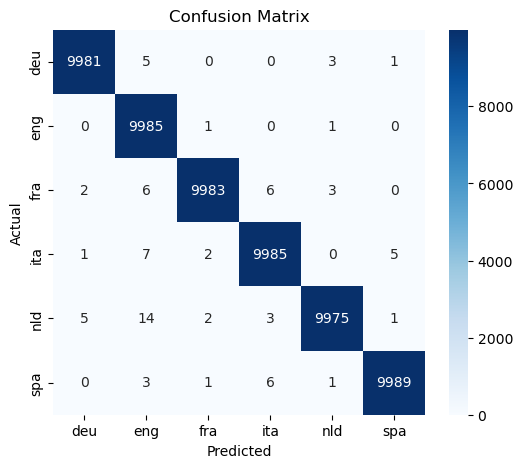

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=II.labels, yticklabels=II.labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Obtenim una precisió del 99,89% la qual cosa ens indica que el model funciona correctament.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 0.9988328859396102


c:\Users\david\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. nan  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.]
  warnings.warn(


Accuracy: 0.9988162128816046


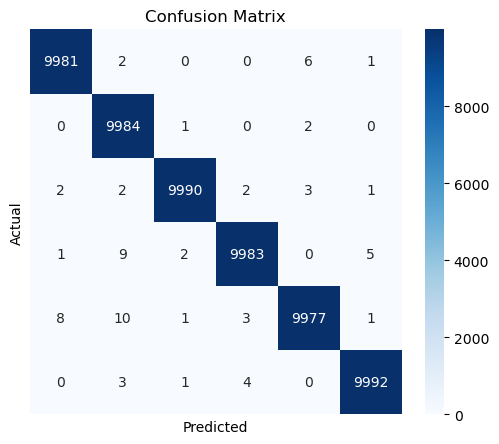

In [ ]:
param_grid = {
    "lambd": [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    "B_compute": ["unified", "not_unified"]
}

II = IdentificadorIdiomas(method="lidstone")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_pos_scorer = make_scorer(accuracy_score)

gs = GridSearchCV(
    estimator=II,
    param_grid=param_grid,
    scoring=f1_pos_scorer,
    cv=cv,
    n_jobs=-1
)

# Run search
gs.fit(X_training, y_training)

best_model = gs.best_estimator_

y_pred = gs.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=II.labels, yticklabels=II.labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(best_model)